In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import datetime as dt

# For forecasting
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error


In [2]:
# Upload from local or use Kaggle API
train = pd.read_csv("../data/train.csv")
test = pd.read_csv("../data/test.csv")
store = pd.read_csv("../data/store.csv")

# Merge store info into train and test
train = pd.merge(train, store, on="Store", how="left")
test = pd.merge(test, store, on="Store", how="left")

train.head()


C:\Users\Shrijith\AppData\Local\Temp\ipykernel_12188\321019160.py:2: DtypeWarning: Columns (7) have mixed types. Specify dtype option on import or set low_memory=False.
  train = pd.read_csv("../data/train.csv")


,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,5,2015-07-31,5263,555,1,1,0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,5,2015-07-31,6064,625,1,1,0,1,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,5,2015-07-31,8314,821,1,1,0,1,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,5,2015-07-31,13995,1498,1,1,0,1,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,5,2015-07-31,4822,559,1,1,0,1,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN


In [3]:
# Check for missing values
train.isnull().sum()

# Convert 'Date' to datetime
train['Date'] = pd.to_datetime(train['Date'])

# Feature engineering: extract year, month, day
train['Year'] = train['Date'].dt.year
train['Month'] = train['Date'].dt.month
train['Day'] = train['Date'].dt.day


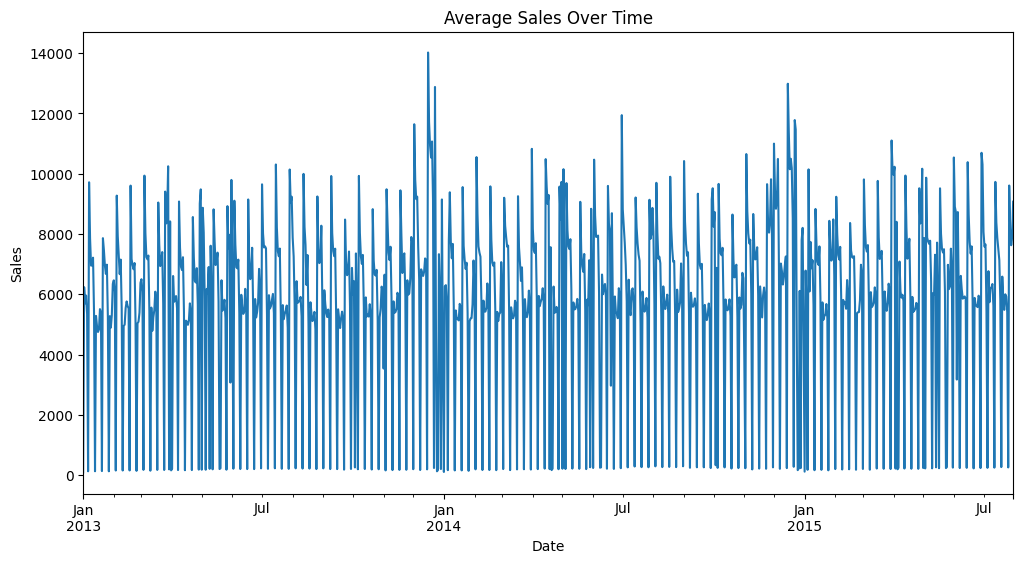

Text(0.5, 1.0, 'Sales vs Promo')

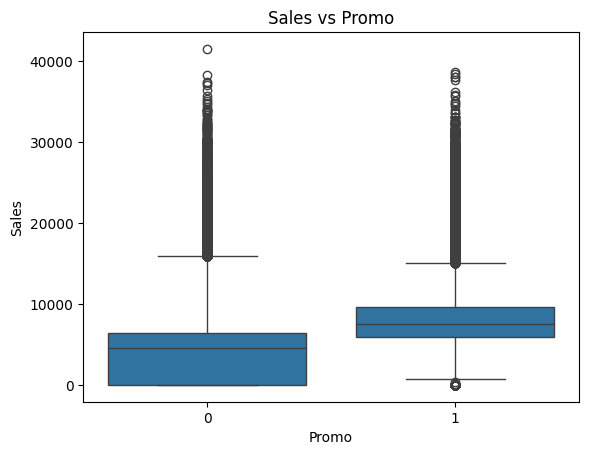

In [4]:
# Plot sales over time
plt.figure(figsize=(12,6))
train.groupby('Date')['Sales'].mean().plot()
plt.title("Average Sales Over Time")
plt.ylabel("Sales")
plt.show()

# Impact of Promo
sns.boxplot(x='Promo', y='Sales', data=train)
plt.title("Sales vs Promo")


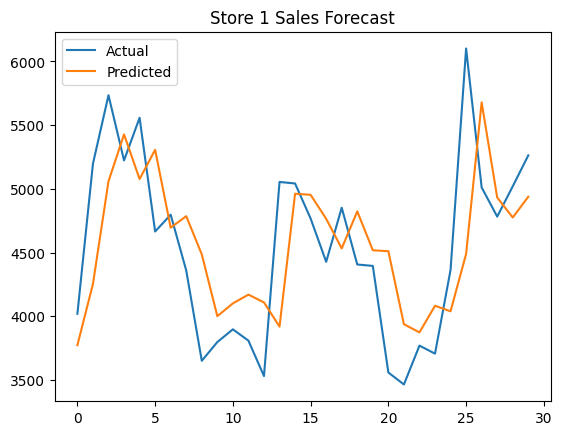

In [5]:
store1 = train[train['Store'] == 1].copy()

# Optional: keep only open days
store1 = store1[store1['Open'] == 1]

store1 = store1.sort_values("Date")
store1['Sales_t-1'] = store1['Sales'].shift(1)

# Drop rows where Sales or lag is NaN
store1 = store1.dropna(subset=['Sales', 'Sales_t-1'])

# Check if data is available
if len(store1) < 30:
    print("⚠️ Not enough data to train the model.")
else:
    X = store1[['Sales_t-1']]
    y = store1['Sales']
    X_train, X_test = X[:-30], X[-30:]
    y_train, y_test = y[:-30], y[-30:]

    model = LinearRegression()
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    # Plot results
    plt.plot(y_test.values, label='Actual')
    plt.plot(y_pred, label='Predicted')
    plt.title("Store 1 Sales Forecast")
    plt.legend()
    plt.show()
